# Run evaluation on the manual annotations against coSMicQC

In [1]:
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from plotnine import (
    aes,
    element_text,
    facet_grid,
    facet_wrap,
    geom_hline,
    geom_point,
    geom_text,
    geom_tile,
    ggplot,
    labs,
    scale_fill_gradient,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from sklearn.metrics import cohen_kappa_score, confusion_matrix


In [2]:
# -----------------------------
# metrics function
# -----------------------------
def compute_metrics(df: pd.DataFrame, pred_col: str, true_col: str) -> dict:
    """
    Compute accuracy, precision, recall, and specificity from a confusion matrix.

    Args:
        df (pd.DataFrame): DataFrame containing the true and predicted labels.
        pred_col (str): Name of the column containing predicted labels.
        true_col (str): Name of the column containing true labels.

    Returns:
        dict: A dictionary containing accuracy, precision, recall, specificity, 
            and number of cells.
    """

    cm = confusion_matrix(df[true_col], df[pred_col], labels=[0, 1])

    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
        "precision": tp / (tp + fp) if (tp + fp) else np.nan,
        "recall": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "n_cells": len(df),
    }


In [3]:
# Set figure directory
figure_dir = Path("./figures")
figure_dir.mkdir(exist_ok=True, parents=True)

# Set path to the stratified sample
sample_path = Path("./data/stratified_qc_sample.parquet")

# Load the stratified sample
qc_sample_df = pd.read_parquet(sample_path)
print("Stratified sample loaded from:", sample_path)
print(qc_sample_df.shape)

annotation_df = qc_sample_df.reset_index(names="sample_row_id").copy()
annotation_df = annotation_df.sample(frac=1, random_state=42).reset_index(drop=True)

preview_columns = [
    column
    for column in [
        "Metadata_cell_line",
        "Metadata_condition",
        "Metadata_Plate",
        "Metadata_Well",
        "Image_Metadata_Row",
        "Image_Metadata_Col",
    ]
    if column in annotation_df.columns
]
annotation_df[preview_columns].head()


Stratified sample loaded from: data/stratified_qc_sample.parquet
(400, 26)


,Metadata_cell_line,Metadata_condition,Metadata_Plate,Metadata_Well,Image_Metadata_Row,Image_Metadata_Col
0,CHLA-10,synthemax_PFA,BR00145816,B09,2,9
1,CHLA-218,synthemax_PFA,BR00145816,I11,9,11
2,CHLA-10,synthemax_PFA,BR00145816,C12,3,12
3,CHLA-10,synthemax_PFA,BR00145816,B07,2,7
4,CHLA-218,synthemax_PFA,BR00145816,I09,9,9


In [4]:
# Set path to manual annotation files from experts
annotation_paths = list(
    Path("./data").rglob("*manual_segmentation_annotations*.parquet")
)

if not annotation_paths:
    raise ValueError("No annotation parquet files found.")

# Concat annotations + add annotator from filename
annotations_df = pd.concat(
    [
        pd.read_parquet(p).assign(
            annotator=p.stem.split("manual_segmentation_annotations")[-1]
        )
        for p in annotation_paths
    ],
    ignore_index=True,
)

# Blind the annotators
annotations_df["annotator"] = annotations_df["annotator"].str.lstrip("_")

annotator_map = {
    annotator: f"Annotator {i + 1}"
    for i, annotator in enumerate(sorted(annotations_df["annotator"].unique()))
}

annotations_df["annotator"] = annotations_df["annotator"].map(annotator_map)


annotations_df.head()


,sample_row_id,manual_segmentation_label,manual_segmentation_is_bad,annotator
0,0,good,False,Annotator 2
1,1,bad,True,Annotator 2
2,2,good,False,Annotator 2
3,3,bad,True,Annotator 2
4,4,bad,True,Annotator 2


In [5]:
manual_eval_df = annotation_df.merge(
    annotations_df,
    on="sample_row_id",
    how="inner",
)

# keep only valid labels
manual_eval_df = manual_eval_df.loc[
    manual_eval_df["manual_segmentation_label"].isin(["good", "bad"])
].copy()

# encode manual labels
manual_eval_df["manual_segmentation_is_bad"] = (
    manual_eval_df["manual_segmentation_label"] == "bad"
).astype(int)

manual_eval_df["failed_qc"] = manual_eval_df["failed_qc"].astype(int)

# -----------------------------
# confusion matrix (split by annotator)
# -----------------------------
confusion_df = (
    manual_eval_df
    .groupby(["annotator", "failed_qc", "manual_segmentation_is_bad"])
    .size()
    .reset_index(name="count")
)

# -----------------------------
# save evaluation dataset
# -----------------------------
manual_eval_df.to_parquet(
    "./data/manual_segmentation_evaluation.parquet",
    index=False
)

print("Evaluation data saved to: ./data/manual_segmentation_evaluation.parquet")

display(confusion_df)


Evaluation data saved to: ./data/manual_segmentation_evaluation.parquet


,annotator,failed_qc,manual_segmentation_is_bad,count
0,Annotator 1,0,0,77
1,Annotator 1,0,1,94
2,Annotator 1,1,0,24
3,Annotator 1,1,1,170
4,Annotator 2,0,0,43
5,Annotator 2,0,1,155
6,Annotator 2,1,0,14
7,Annotator 2,1,1,186


In [6]:
annotations_df["manual_segmentation_label"].value_counts()


manual_segmentation_label
bad       605
good      158
unsure     37
Name: count, dtype: int64

## Cohen's k plot per comparison across cell lines 

In [7]:
results = []

cell_lines = manual_eval_df["Metadata_cell_line"].unique()

for cl in cell_lines:

    df_cl = manual_eval_df[manual_eval_df["Metadata_cell_line"] == cl]

    # split annotators
    a1 = df_cl[df_cl["annotator"] == "Annotator 1"][
        ["sample_row_id", "manual_segmentation_is_bad", "failed_qc"]
    ]

    a2 = df_cl[df_cl["annotator"] == "Annotator 2"][
        ["sample_row_id", "manual_segmentation_is_bad", "failed_qc"]
    ]

    # -----------------------------
    # align A1 vs A2 (human baseline)
    # -----------------------------
    human = a1.merge(
        a2,
        on="sample_row_id",
        suffixes=("_a1", "_a2")
    )

    if len(human) > 1:
        kappa_a1_a2 = cohen_kappa_score(
            human["manual_segmentation_is_bad_a1"],
            human["manual_segmentation_is_bad_a2"],
        )
    else:
        kappa_a1_a2 = np.nan

    # -----------------------------
    # model vs A1
    # -----------------------------
    if len(a1) > 0:
        kappa_model_a1 = cohen_kappa_score(
            a1["failed_qc"],
            a1["manual_segmentation_is_bad"],
        )
    else:
        kappa_model_a1 = np.nan

    # -----------------------------
    # model vs A2
    # -----------------------------
    if len(a2) > 0:
        kappa_model_a2 = cohen_kappa_score(
            a2["failed_qc"],
            a2["manual_segmentation_is_bad"],
        )
    else:
        kappa_model_a2 = np.nan

    results.append({
        "cell_line": cl,
        "kappa_A1_A2": kappa_a1_a2,
        "kappa_model_A1": kappa_model_a1,
        "kappa_model_A2": kappa_model_a2,
    })

kappa_df = pd.DataFrame(results)

print("Per cell line κ:")
print(kappa_df)

print("\nMean ± SD across cell lines:")
print(
    kappa_df[
        ["kappa_A1_A2", "kappa_model_A1", "kappa_model_A2"]
    ].agg(["mean", "std"])
)

# -----------------------------
# OVERALL κ (pooled across all cell lines)
# -----------------------------
human_all = manual_eval_df.merge(
    manual_eval_df,
    on="sample_row_id",
    suffixes=("_a1", "_a2")
)

human_all = human_all[
    (human_all["annotator_a1"] == "Annotator 1") &
    (human_all["annotator_a2"] == "Annotator 2")
]

overall_kappa = cohen_kappa_score(
    human_all["manual_segmentation_is_bad_a1"],
    human_all["manual_segmentation_is_bad_a2"],
)

print("\nOverall κ (pooled across all cell lines):")
print(overall_kappa)


Per cell line κ:
  cell_line  kappa_A1_A2  kappa_model_A1  kappa_model_A2
0   CHLA-10     0.257812        0.516949        0.175000
1  CHLA-218     0.266376        0.495050        0.181877
2   CHLA-25    -0.005464        0.209078        0.175000
3  CHLA-113     0.209964        0.082073        0.130744
4     U2-OS     0.164367        0.354458        0.075000

Mean ± SD across cell lines:
      kappa_A1_A2  kappa_model_A1  kappa_model_A2
mean     0.178611        0.331522        0.147524
std      0.110731        0.186325        0.045363

Overall κ (pooled across all cell lines):
0.21793016102768226


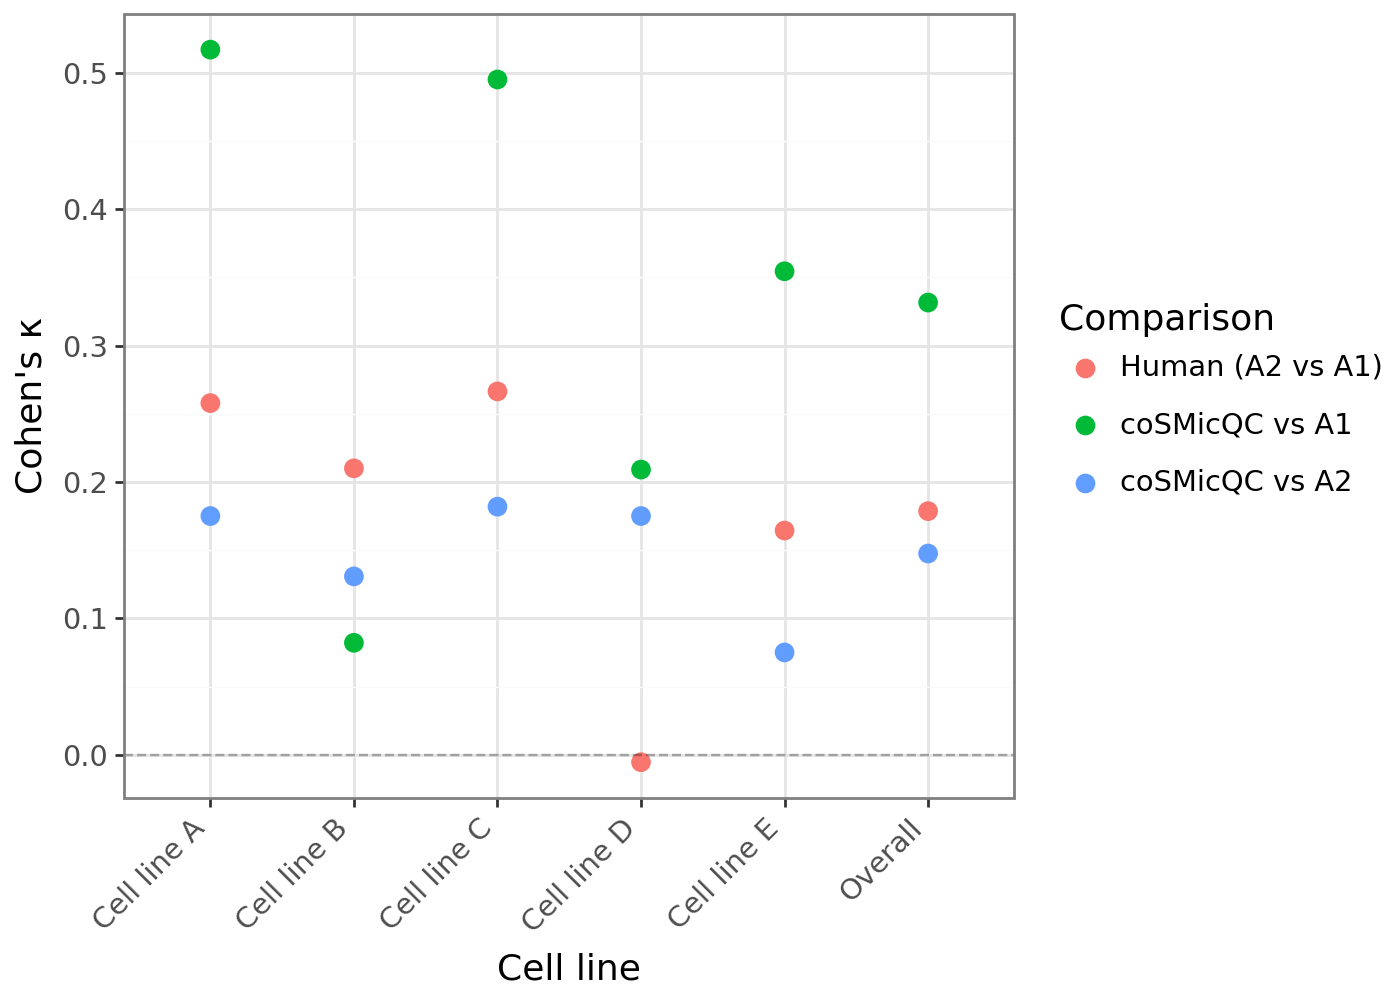

In [8]:
# -----------------------------
# reshape to long format
# -----------------------------
plot_df = kappa_df.melt(
    id_vars="cell_line",
    value_vars=["kappa_A1_A2", "kappa_model_A1", "kappa_model_A2"],
    var_name="comparison",
    value_name="kappa",
)

# -----------------------------
# label cleanup
# -----------------------------
label_map = {
    "kappa_A1_A2": "Human (A2 vs A1)",
    "kappa_model_A1": "coSMicQC vs A1",
    "kappa_model_A2": "coSMicQC vs A2",
}

plot_df["comparison"] = plot_df["comparison"].map(label_map)

# -----------------------------
# add overall mean summary row
# -----------------------------
overall = kappa_df[
    ["kappa_A1_A2", "kappa_model_A1", "kappa_model_A2"]
].mean()

overall_df = pd.DataFrame({
    "cell_line": ["Overall"] * 3,
    "comparison": [
        "Human (A2 vs A1)",
        "coSMicQC vs A1",
        "coSMicQC vs A2",
    ],
    "kappa": [
        overall["kappa_A1_A2"],
        overall["kappa_model_A1"],
        overall["kappa_model_A2"],
    ],
})

plot_df = pd.concat([plot_df, overall_df], ignore_index=True)

# enforce categorical alignment
cell_order = [*list(kappa_df["cell_line"].unique()), "Overall"]

plot_df["cell_line"] = pd.Categorical(
    plot_df["cell_line"],
    categories=cell_order,
    ordered=True
)

# Cell line mapping (blinded names)
cell_line_map = {
    "CHLA-10": "Cell line A",
    "CHLA-113": "Cell line B",
    "CHLA-218": "Cell line C",
    "CHLA-25": "Cell line D",
    "U2-OS": "Cell line E",
    "Overall": "Overall"
}

plot_df["cell_line"] = plot_df["cell_line"].astype(str).map(cell_line_map)

# -----------------------------
# plot
# -----------------------------
width = 7
height = 5
set_option("figure_size", (width, height))

p = (
    ggplot(
        plot_df,
        aes(
            x="cell_line",
            y="kappa",
            color="comparison"
        )
    )
    + geom_point(size=3)

    + geom_hline(
        yintercept=0,
        linetype="dashed",
        alpha=0.3
    )

    + labs(
        x="Cell line",
        y="Cohen's κ",
        color="Comparison",
    )

    + theme_bw(base_size=13)
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

p.save(
    figure_dir / "kappa_human_vs_model.png",
    width=width,
    height=height,
    dpi=600,
    verbose=False,
)

p.show()


## Generate confusion matrix data to compute performance metrics

In [9]:
# --- column-normalized proportions (within annotator + manual decision) ---
confusion_df["col_sum"] = confusion_df.groupby(
    ["annotator", "manual_segmentation_is_bad"]
)["count"].transform("sum")

confusion_df["proportion"] = confusion_df["count"] / confusion_df["col_sum"]
confusion_df["proportion"] = confusion_df["proportion"].fillna(0)

# -----------------------------
# pretty labels for plotting
# -----------------------------
confusion_df["coSMicQC failed_qc"] = confusion_df["failed_qc"].map(
    {1: "Failed QC", 0: "Passed QC"}
)

confusion_df["Manual bad segmentation"] = confusion_df["manual_segmentation_is_bad"].map(
    {1: "Failed QC", 0: "Passed QC"}
)

# optional ordering for nicer plots
confusion_df["coSMicQC failed_qc"] = pd.Categorical(
    confusion_df["coSMicQC failed_qc"],
    categories=["Passed QC", "Failed QC"],
    ordered=True
)

confusion_df["Manual bad segmentation"] = pd.Categorical(
    confusion_df["Manual bad segmentation"],
    categories=["Passed QC", "Failed QC"],
    ordered=True
)

# -----------------------------
# save evaluation dataset (optional but useful)
# -----------------------------
manual_eval_df.to_parquet(
    "./data/manual_segmentation_evaluation.parquet",
    index=False
)

print("Evaluation data saved to: ./data/manual_segmentation_evaluation.parquet")

display(confusion_df)


Evaluation data saved to: ./data/manual_segmentation_evaluation.parquet


,annotator,failed_qc,manual_segmentation_is_bad,count,col_sum,proportion,coSMicQC failed_qc,Manual bad segmentation
0,Annotator 1,0,0,77,101,0.762376,Passed QC,Passed QC
1,Annotator 1,0,1,94,264,0.356061,Passed QC,Failed QC
2,Annotator 1,1,0,24,101,0.237624,Failed QC,Passed QC
3,Annotator 1,1,1,170,264,0.643939,Failed QC,Failed QC
4,Annotator 2,0,0,43,57,0.754386,Passed QC,Passed QC
5,Annotator 2,0,1,155,341,0.454545,Passed QC,Failed QC
6,Annotator 2,1,0,14,57,0.245614,Failed QC,Passed QC
7,Annotator 2,1,1,186,341,0.545455,Failed QC,Failed QC


In [10]:
# -----------------------------
# MAIN LOOP
# -----------------------------
results = []

cell_lines = manual_eval_df["Metadata_cell_line"].unique()

for cl in cell_lines:

    df_cl = manual_eval_df[manual_eval_df["Metadata_cell_line"] == cl]

    # split annotators
    a1 = df_cl[df_cl["annotator"] == "Annotator 1"]
    a2 = df_cl[df_cl["annotator"] == "Annotator 2"]

    # -----------------------------
    # MODEL vs Annotator 1
    # -----------------------------
    if len(a1) > 0:
        row = compute_metrics(
            a1,
            pred_col="failed_qc",
            true_col="manual_segmentation_is_bad"
        )

        row["comparison"] = "coSMicQC vs Annotator 1"
        row["cell_line"] = cl
        results.append(row)

    # -----------------------------
    # MODEL vs Annotator 2
    # -----------------------------
    if len(a2) > 0:
        row = compute_metrics(
            a2,
            pred_col="failed_qc",
            true_col="manual_segmentation_is_bad"
        )

        row["comparison"] = "coSMicQC vs Annotator 2"
        row["cell_line"] = cl
        results.append(row)

    # -----------------------------
    # HUMAN vs HUMAN baseline
    # -----------------------------
    human = a1.merge(
        a2,
        on="sample_row_id",
        suffixes=("_a1", "_a2")
    )

    if len(human) > 0:
        row = compute_metrics(
            human,
            pred_col="manual_segmentation_is_bad_a2",
            true_col="manual_segmentation_is_bad_a1"
        )

        row["comparison"] = "Human (A2 vs A1)"
        row["cell_line"] = cl
        results.append(row)


metrics_df = pd.DataFrame(results)
metrics_df.head()


,accuracy,precision,recall,specificity,n_cells,comparison,cell_line
0,0.763158,0.925000,0.711538,0.875000,76,coSMicQC vs Annotator 1,CHLA-10
1,0.587500,0.975000,0.549296,0.888889,80,coSMicQC vs Annotator 2,CHLA-10
2,0.736842,0.735294,0.961538,0.250000,76,Human (A2 vs A1),CHLA-10
3,0.763889,1.000000,0.701754,1.000000,72,coSMicQC vs Annotator 1,CHLA-218
4,0.594937,0.975000,0.557143,0.888889,79,coSMicQC vs Annotator 2,CHLA-218


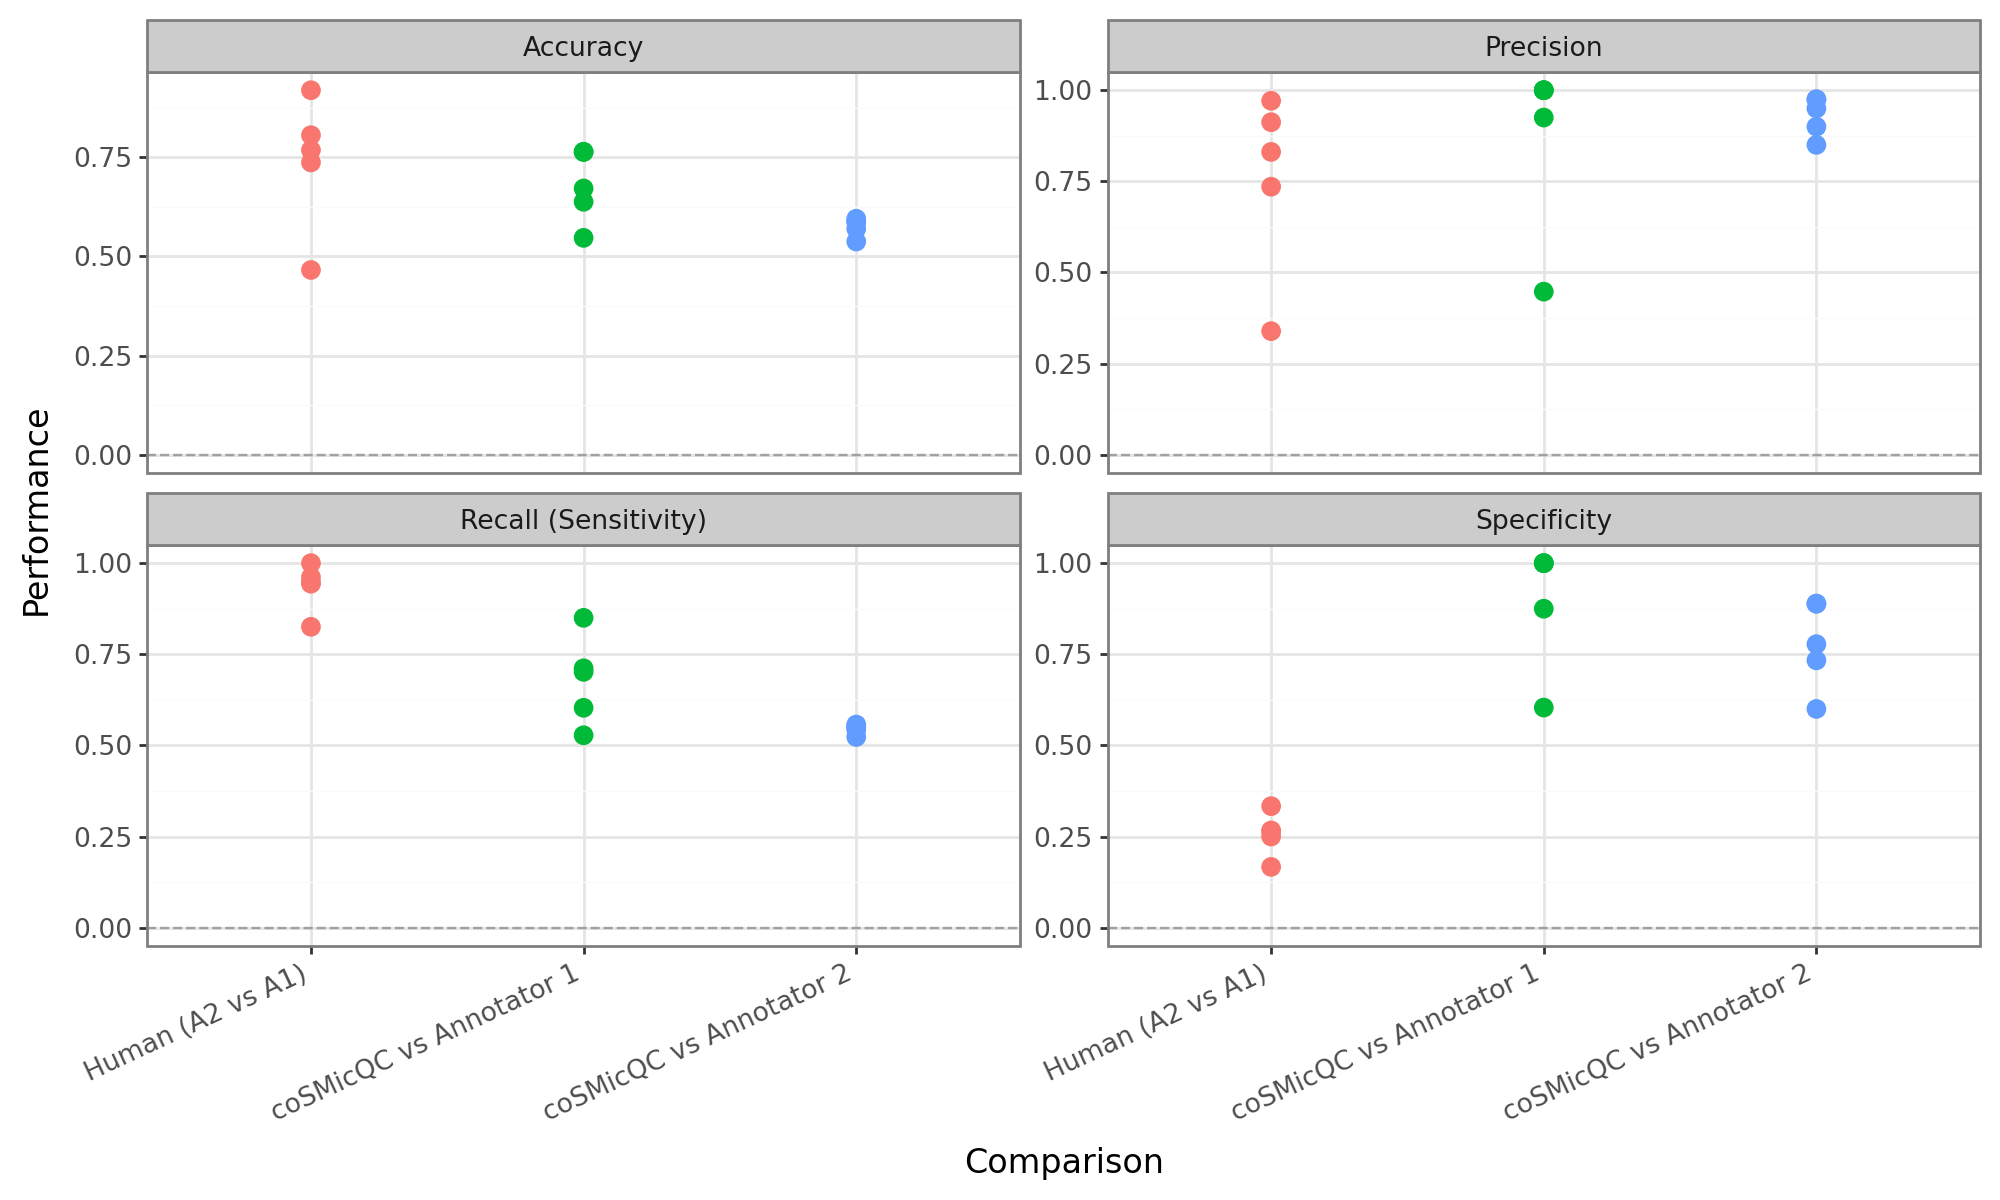

In [11]:
# -----------------------------
# reshape to long format
# -----------------------------
plot_df = metrics_df.melt(
    id_vars=["cell_line", "comparison"],
    value_vars=[
        "accuracy",
        "precision",
        "recall",
        "specificity"
    ],
    var_name="metric",
    value_name="value"
)

# -----------------------------
# clean metric names
# -----------------------------
metric_map = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall (Sensitivity)",
    "specificity": "Specificity"
}

plot_df["metric"] = plot_df["metric"].map(metric_map)

# -----------------------------
# enforce ordering
# -----------------------------
metric_order = [
    "Accuracy",
    "Precision",
    "Recall (Sensitivity)",
    "Specificity"
]

plot_df["metric"] = pd.Categorical(
    plot_df["metric"],
    categories=metric_order,
    ordered=True
)

# -----------------------------
# plot
# -----------------------------
width = 7
height = 5

set_option("figure_size", (width, height))

p = (
    ggplot(
        plot_df,
        aes(
            x="comparison",
            y="value",
            color="comparison"
        )
    )

    # metric points
    + geom_point(size=3)

    # facet by metric
    + facet_wrap("~metric", scales="free_y")

    + geom_hline(
        yintercept=0,
        linetype="dashed",
        alpha=0.3
    )

    + labs(
        x="Comparison",
        y="Performance"
    )

    + theme_bw(base_size=12)
    + theme(
        axis_text_x=element_text(rotation=25, hjust=1),
        figure_size=(10, 6),
        legend_position="none"
    )
)

p.save(
    figure_dir / "model_performance_versus_annotators.png",
    dpi=600,
    width=width,
    height=height,
    verbose=False,
)

p.show()


In [12]:
human_df = metrics_df[metrics_df["comparison"] == "Human (A2 vs A1)"]
model_df = metrics_df[metrics_df["comparison"].str.startswith("coSMicQC vs")]

print("="*60)
print("ACCURACY AND PRECISION RANGE SUMMARY")
print("="*60)

for metric in ["accuracy", "precision"]:
    human_min = human_df[metric].min()
    human_max = human_df[metric].max()

    combined_vals = pd.concat([human_df[metric], model_df[metric]])
    overall_min = combined_vals.min()
    overall_max = combined_vals.max()

    model_vals = model_df[metric]
    n_total = len(model_vals)
    n_within = ((model_vals >= human_min) & (model_vals <= human_max)).sum()
    n_above = (model_vals > human_max).sum()
    n_below = (model_vals < human_min).sum()

    print(f"\n{metric.upper()}")
    print(f"  Human annotator range:       {human_min:.2f}-{human_max:.2f}")
    print(f"  coSMicQC comparisons within human range: {n_within}/{n_total}")
    print(f"  coSMicQC comparisons ABOVE human range:   {n_above}/{n_total}")
    print(f"  coSMicQC comparisons BELOW human range:   {n_below}/{n_total}")

print("\n" + "="*60)


ACCURACY AND PRECISION RANGE SUMMARY

ACCURACY
  Human annotator range:       0.47-0.92
  coSMicQC comparisons within human range: 10/10
  coSMicQC comparisons ABOVE human range:   0/10
  coSMicQC comparisons BELOW human range:   0/10

PRECISION
  Human annotator range:       0.34-0.97
  coSMicQC comparisons within human range: 5/10
  coSMicQC comparisons ABOVE human range:   5/10
  coSMicQC comparisons BELOW human range:   0/10



## Generate confusion matrices comaparing coSMicQc to each annotator and the annotators to each other

In [13]:
# --- long-format confusion matrix per cell line + annotator ---
cm_df_cell_line = (
    manual_eval_df
    .groupby([
        "annotator",
        "Metadata_cell_line",
        "failed_qc",
        "manual_segmentation_is_bad"
    ])
    .size()
    .reset_index(name="count")
)

# -----------------------------
# FORCE FULL 2x2 GRID PER FACET
# -----------------------------
full_index = pd.DataFrame(
    itertools.product(
        cm_df_cell_line["annotator"].unique(),
        cm_df_cell_line["Metadata_cell_line"].unique(),
        [0, 1],
        [0, 1],
    ),
    columns=[
        "annotator",
        "Metadata_cell_line",
        "failed_qc",
        "manual_segmentation_is_bad",
    ],
)

cm_df_cell_line = full_index.merge(
    cm_df_cell_line,
    on=[
        "annotator",
        "Metadata_cell_line",
        "failed_qc",
        "manual_segmentation_is_bad",
    ],
    how="left",
)

cm_df_cell_line["count"] = cm_df_cell_line["count"].fillna(0)

# -----------------------------
# Compute column normalized proportions
# -----------------------------
cm_df_cell_line["col_sum"] = cm_df_cell_line.groupby(
    ["annotator", "Metadata_cell_line", "manual_segmentation_is_bad"]
)["count"].transform("sum")

cm_df_cell_line["proportion"] = (
    cm_df_cell_line["count"] / cm_df_cell_line["col_sum"]
)

cm_df_cell_line["proportion"] = cm_df_cell_line["proportion"].fillna(0)

# -----------------------------
# pretty labels
# -----------------------------
cm_df_cell_line["coSMicQC failed_qc"] = cm_df_cell_line["failed_qc"].map(
    {1: "Failed QC", 0: "Passed QC"}
)

cm_df_cell_line["Manual bad segmentation"] = cm_df_cell_line[
    "manual_segmentation_is_bad"
].map(
    {1: "Failed QC", 0: "Passed QC"}
)

cm_df_cell_line["count"] = cm_df_cell_line["count"].fillna(0).astype(int)

cm_df_cell_line.head()


,annotator,Metadata_cell_line,failed_qc,manual_segmentation_is_bad,count,col_sum,proportion,coSMicQC failed_qc,Manual bad segmentation
0,Annotator 1,CHLA-10,0,0,21,24.0,0.875000,Passed QC,Passed QC
1,Annotator 1,CHLA-10,0,1,15,52.0,0.288462,Passed QC,Failed QC
2,Annotator 1,CHLA-10,1,0,3,24.0,0.125000,Failed QC,Passed QC
3,Annotator 1,CHLA-10,1,1,37,52.0,0.711538,Failed QC,Failed QC
4,Annotator 1,CHLA-113,0,0,3,3.0,1.000000,Passed QC,Passed QC


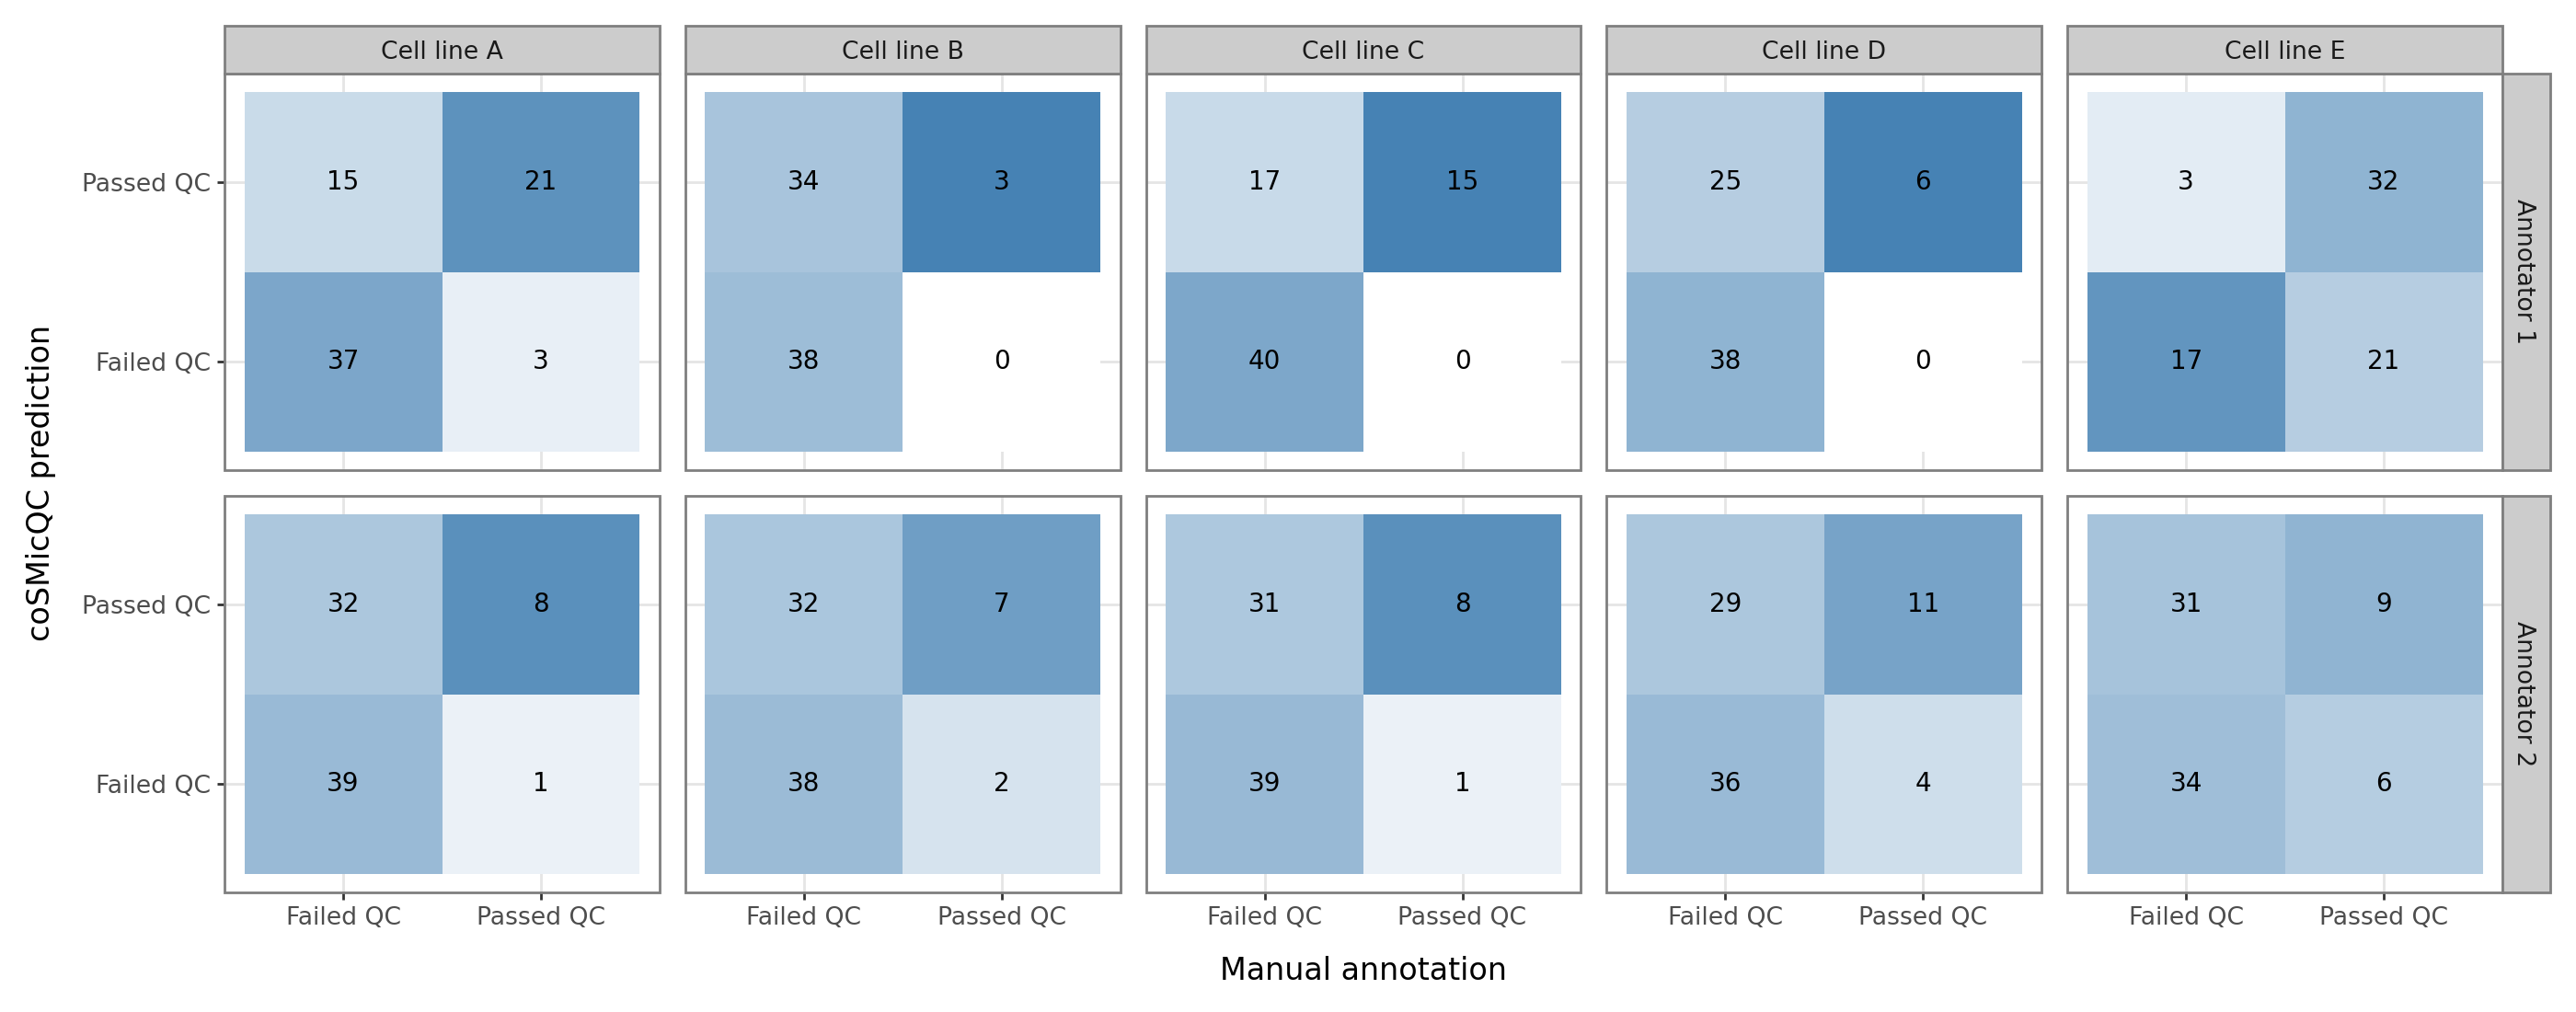

In [14]:
# -----------------------------
# Cell line mapping (blinded names)
# -----------------------------
cell_line_map = {
    "CHLA-10": "Cell line A",
    "CHLA-113": "Cell line B",
    "CHLA-218": "Cell line C",
    "CHLA-25": "Cell line D",
    "U2-OS": "Cell line E",
}

cm_df_cell_line["Cell_line"] = cm_df_cell_line["Metadata_cell_line"].map(cell_line_map)

# Set the figure size
width = 14
height = 5.5
set_option("figure_size", (width, height))

p_cm = (
    ggplot(cm_df_cell_line)
    + aes(
        x="Manual bad segmentation",
        y="coSMicQC failed_qc",
        fill="proportion",
    )
    + geom_tile()
    + geom_text(aes(label="count"), size=10)
    + facet_grid("annotator ~ Cell_line")
    + scale_fill_gradient(low="white", high="steelblue", limits=(0, 1))
    + labs(
        x="Manual annotation",
        y="coSMicQC prediction",
        fill="Column-normalized\nproportion",
    )
    + theme_bw(base_size=12)
    + theme(legend_position="none")
)

p_cm.save(
    figure_dir / "manual_annotation_confusion_matrix_facet_celltype.png",
    dpi=600,
    width=width,
    height=height,
    verbose=False,
)
p_cm.show()


In [15]:
# -----------------------------
# sample_row_id uniquely identifies a sample — use it directly
# -----------------------------
id_col = "sample_row_id"

annotators = sorted(manual_eval_df["annotator"].unique())
ann1, ann2 = annotators[0], annotators[1]

# -----------------------------
# Pull sample-level metadata (should be constant across annotators for the same sample_row_id)
# -----------------------------
sample_meta = (
    manual_eval_df
    .drop_duplicates(subset=[id_col])
    [[id_col, "Metadata_cell_line", "failed_qc"]]
)

# -----------------------------
# Pivot manual_segmentation_is_bad wide by annotator, per sample
# -----------------------------
wide_df = manual_eval_df.pivot_table(
    index=id_col,
    columns="annotator",
    values="manual_segmentation_is_bad",
    aggfunc="first",
).reset_index()

wide_df = wide_df.rename(columns={ann1: "annotator_1_seg", ann2: "annotator_2_seg"})
wide_df = wide_df.dropna(subset=["annotator_1_seg", "annotator_2_seg"])

# merge back in cell line + failed_qc
wide_df = wide_df.merge(sample_meta, on=id_col, how="left")
wide_df.head()


,sample_row_id,annotator_1_seg,annotator_2_seg,Metadata_cell_line,failed_qc
0,1,1.0,1.0,CHLA-10,0
1,2,0.0,0.0,CHLA-10,0
2,3,1.0,1.0,CHLA-10,0
3,4,0.0,1.0,CHLA-10,0
4,5,1.0,1.0,CHLA-10,0


In [16]:
# -----------------------------
# long-format confusion matrix: per cell line + failed_qc,
# annotator 1 (y) vs annotator 2 (x) segmentation labels
# -----------------------------
cm_df_cell_line = (
    wide_df
    .groupby(["Metadata_cell_line", "failed_qc", "annotator_1_seg", "annotator_2_seg"])
    .size()
    .reset_index(name="count")
)

# -----------------------------
# FORCE FULL 2x2 GRID PER FACET
# -----------------------------
full_index = pd.DataFrame(
    itertools.product(
        cm_df_cell_line["Metadata_cell_line"].unique(),
        [0, 1],  # failed_qc
        [0, 1],  # annotator_1_seg
        [0, 1],  # annotator_2_seg
    ),
    columns=["Metadata_cell_line", "failed_qc", "annotator_1_seg", "annotator_2_seg"],
)

cm_df_cell_line = full_index.merge(
    cm_df_cell_line,
    on=["Metadata_cell_line", "failed_qc", "annotator_1_seg", "annotator_2_seg"],
    how="left",
)
cm_df_cell_line["count"] = cm_df_cell_line["count"].fillna(0)

# -----------------------------
# pretty labels
# -----------------------------
label_map = {1: "Failed QC", 0: "Passed QC"}
cm_df_cell_line["coSMicQC failed_qc"] = cm_df_cell_line["failed_qc"].map(label_map)
cm_df_cell_line["Annotator 1"] = cm_df_cell_line["annotator_1_seg"].map(label_map)
cm_df_cell_line["Annotator 2"] = cm_df_cell_line["annotator_2_seg"].map(label_map)
cm_df_cell_line["count"] = cm_df_cell_line["count"].astype(int)

# -----------------------------
# Collapse across failed_qc so each cell line facet has one clean 2x2 grid
# -----------------------------
cm_df_cell_line_collapsed = (
    cm_df_cell_line
    .groupby(["Metadata_cell_line", "Annotator 1", "Annotator 2"])["count"]
    .sum()
    .reset_index()
)

cm_df_cell_line_collapsed["col_sum"] = cm_df_cell_line_collapsed.groupby(
    ["Metadata_cell_line", "Annotator 2"]
)["count"].transform("sum")

cm_df_cell_line_collapsed["proportion"] = (
    cm_df_cell_line_collapsed["count"] / cm_df_cell_line_collapsed["col_sum"]
).fillna(0)

cm_df_cell_line_collapsed.head()


,Metadata_cell_line,Annotator 1,Annotator 2,count,col_sum,proportion
0,CHLA-10,Failed QC,Failed QC,50,68,0.735294
1,CHLA-10,Failed QC,Passed QC,2,8,0.250000
2,CHLA-10,Passed QC,Failed QC,18,68,0.264706
3,CHLA-10,Passed QC,Passed QC,6,8,0.750000
4,CHLA-113,Failed QC,Failed QC,67,69,0.971014


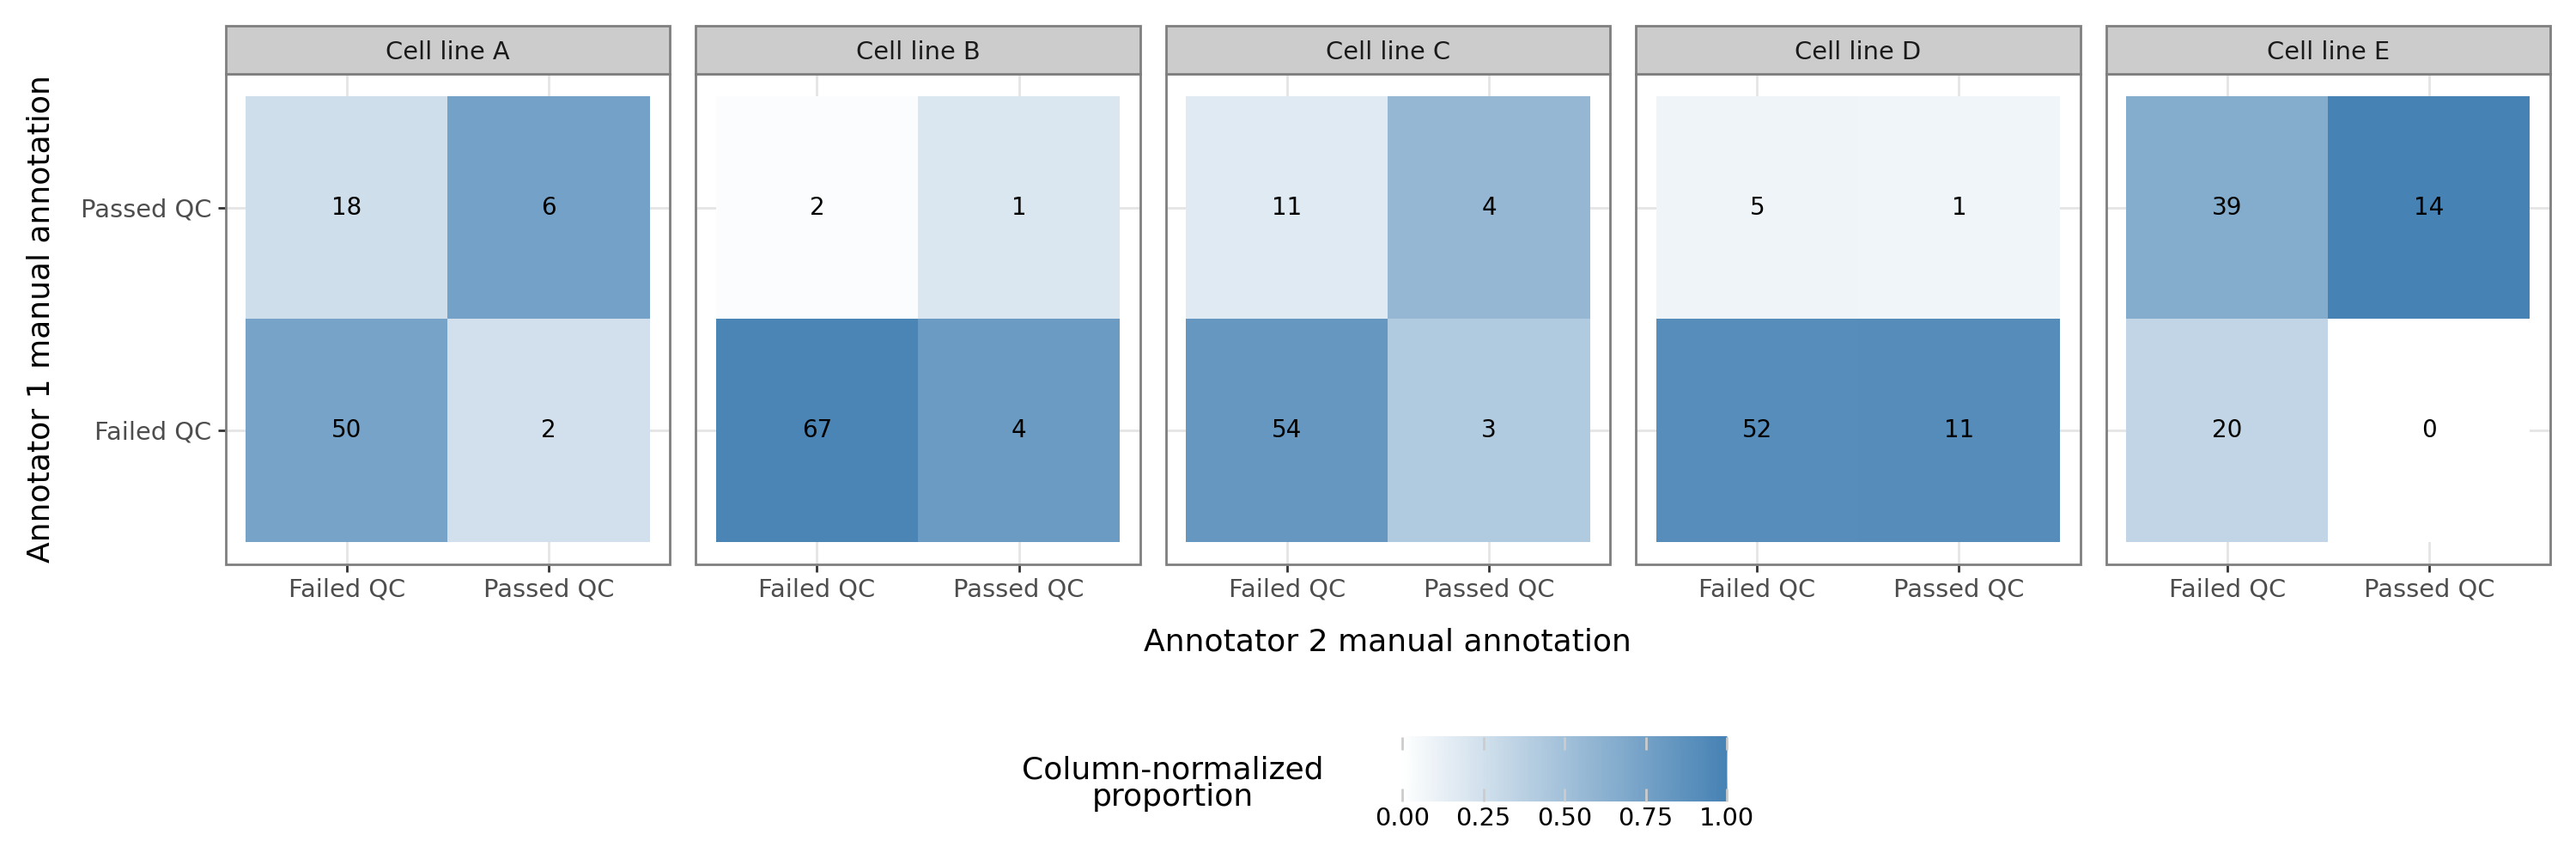

In [17]:
# -----------------------------
# Cell line mapping (blinded names)
# -----------------------------
cell_line_map = {
    "CHLA-10": "Cell line A",
    "CHLA-113": "Cell line B",
    "CHLA-218": "Cell line C",
    "CHLA-25": "Cell line D",
    "U2-OS": "Cell line E",
}

cm_df_cell_line_collapsed["Cell_line"] = cm_df_cell_line_collapsed[
    "Metadata_cell_line"
].map(cell_line_map)

width = 15
height = 5
set_option("figure_size", (width, height))

p_cm = (
    ggplot(cm_df_cell_line_collapsed)
    + aes(
        x="Annotator 2",
        y="Annotator 1",
        fill="proportion",
    )
    + geom_tile()
    + geom_text(aes(label="count"), size=10)
    + facet_wrap("~Cell_line", nrow=1)
    + scale_fill_gradient(low="white", high="steelblue", limits=(0, 1))
    + labs(
        x="Annotator 2 manual annotation",
        y="Annotator 1 manual annotation",
        fill="Column-normalized\nproportion",
    )
    + theme_bw(base_size=13)
    + theme(legend_position="bottom")
)

p_cm.save(
    figure_dir / "annotator_comparison_confusion_matrix_facet_celltype.png",
    dpi=600,
    width=width,
    height=height,
    verbose=False,
)
p_cm.show()
